# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet('data/tracks.parquet')
catalog_names = pd.read_parquet('data/catalog_names.parquet')
interactions = pd.read_parquet('data/interactions.parquet')

In [4]:
# Для удобства переименуем колонки
tracks.rename(columns={
    'albums': 'album',
    'genres': 'genre',
    'artists': 'artist'}, inplace=True)

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

tracks

In [5]:
tracks.sample(8).T

,771293,707126,70799,523847,571,549786,631242,661486
track_id,59365479,52158961,651477,36285210,3200,37879956,44033948,46907297
album,"[9091888, 9091943]","[7326557, 7898515]",[70193],[4563669],"[321, 4206, 6193297, 6195278]",[4814236],[299046],[6337144]
artist,[1047810],[7180704],[75628],[342639],[2561],[3946101],[155914],[1167310]
genre,"[11, 20]",[68],[11],"[40, 47]","[11, 74]",[70],"[11, 20]","[44, 75]"


In [6]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   album     1000000 non-null  object
 2   artist    1000000 non-null  object
 3   genre     1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [7]:
print('Описательная статистика')
tracks.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
track_id,1000000.0,3.685121e+07,2.679771e+07,26.0,15430882.75,34550465.5,56925570.75,101521819.0


In [8]:
print('Незаполненные значения')
pd.DataFrame(tracks.isnull().sum()).T

Незаполненные значения


,track_id,album,artist,genre
0,0,0,0,0


In [9]:
# Проверим заполненность имён
tracks_ids = set(tracks['track_id'].unique())
tracks_names = set(catalog_names.query('type == "track"')['id'].unique())
logging.info(f'Количество "track" без имени: {len(tracks_ids - tracks_names)}')

def count_nameless_prop(prop: str):
    '''Рассчитывает количество безымянных значений свойства "prop"'''
    ids_count = set(tracks[[prop]].explode(prop, ignore_index=True)[prop].unique())
    names_count = set(catalog_names.query('type == @prop')['id'].unique())
    logging.info(f'Количество "{prop}" без имени: {len(ids_count - names_count)}')

count_nameless_prop('album')
count_nameless_prop('genre')
count_nameless_prop('artist')

Количество "track" без имени: 0
Количество "album" без имени: 1
Количество "genre" без имени: 31
Количество "artist" без имени: 1


In [10]:
def max_len_prop(prop: str):
    '''Рассчитывает максимальную длину свойства "prop"'''
    max_len = tracks[['track_id', prop]].explode(prop) \
        .groupby(['track_id']).agg(len=(prop, 'count')).reset_index()['len'].max()
    
    logging.info(f'Максимальная длина свойства "{prop}": {max_len}')

max_len_prop('album')
max_len_prop('genre')
max_len_prop('artist')

Максимальная длина свойства "album": 2844
Максимальная длина свойства "genre": 10
Максимальная длина свойства "artist": 26


In [11]:
# Вычислим количество дубликатов для свойства
def duplicate_count_prop(prop: str):
    '''Рассчитывает количество дубликатов свойства "prop"'''
    duplicate_count = tracks.explode(prop)[['track_id', prop]] \
        .merge(catalog_names.query('type == @prop'), left_on=prop, right_on='id')[['track_id', 'name', 'id']] \
        .groupby(['track_id', 'name']).agg(count=('id', 'count')).reset_index() \
        .query('count > 1') \
        ['name'].nunique()
        
    logging.info(f'Количество дубликатов свойства "{prop}": {duplicate_count}')
        
duplicate_count_prop('album')
duplicate_count_prop('genre')
duplicate_count_prop('artist')         

Количество дубликатов свойства "album": 47868
Количество дубликатов свойства "genre": 0
Количество дубликатов свойства "artist": 43


catalog_names

In [12]:
catalog_names.sample(8).T

,586411,1152587,260440,1168886,1476539,330694,1612162,1092153
id,15248461,22047528,4116207,23861949,47130473,5589257,62561396,17696194
type,album,track,album,track,track,album,track,track
name,Sólo Amor,Empire Falls,A State Of Trance - Future Favorite Best Of 2016,Play My Game,Mytime,Air Max,Impossible,Forest Fire


In [13]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [14]:
print('Описательная статистика')
catalog_names.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
id,1812471.0,2.321647e+07,2.526044e+07,0.0,3480524.0,12114360.0,37738170.0,101521819.0


In [15]:
print('Незаполненные значения')
pd.DataFrame(catalog_names.isnull().sum()).T

Незаполненные значения


,id,type,name
0,0,0,0


In [16]:
print('Уникальные значения свойства "type"')
pd.DataFrame(catalog_names["type"].value_counts()).T

Уникальные значения свойства "type"


type,track,album,artist,genre
count,1000000,658724,153581,166


interactions

In [17]:
interactions.sample(8).T

,1148,10,47,12,458,281,2,437
user_id,327211,221278,427719,687145,1212460,825482,1182854,197703
track_id,49263583,6098607,40498612,51400682,58085423,59852540,7786,52381828
track_seq,1149,11,48,13,459,282,3,438
started_at,2022-09-22 00:00:00,2022-09-11 00:00:00,2022-08-25 00:00:00,2022-11-18 00:00:00,2022-11-16 00:00:00,2022-12-14 00:00:00,2022-09-22 00:00:00,2022-09-26 00:00:00


In [18]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [19]:
print('Описательная статистика')
interactions.describe().T

Описательная статистика


,count,mean,min,25%,50%,75%,max,std
user_id,222629898.0,687576.660624,0.0,343371.0,687973.0,1031127.0,1374582.0,396903.293288
track_id,222629898.0,36536224.961649,26.0,14808489.0,35524737.0,56511373.0,101521819.0,26617816.837147
track_seq,222629898.0,462.140293,1.0,56.0,181.0,506.0,16637.0,825.731213
started_at,222629898,2022-08-29 16:39:44.541336320,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-09-15 00:00:00,2022-11-09 00:00:00,2022-12-31 00:00:00,NaN


In [20]:
print('Незаполненные значения')    
pd.DataFrame(interactions.isnull().sum()).T

Незаполненные значения


,user_id,track_id,track_seq,started_at
0,0,0,0,0


In [21]:
msg = 'Количество взаимодействий, для которых нет информации о треках'
val = interactions[~interactions['track_id'].isin(tracks['track_id'].unique())].shape[0]

logging.info(f'{msg}:{val}')

Количество взаимодействий, для которых нет информации о треках:0


In [22]:
logging.info(f'Количество уникальных пользователей:{interactions["user_id"].nunique()}')

Количество уникальных пользователей:1373221


# Выводы

Приведём выводы по первому знакомству с данными:
- Количество "track" без имени: 0
- Количество "album" без имени: 1
- Количество "genre" без имени: 31
- Количество "artist" без имени: 1
- Максимальная длина свойства "album": 2844
- Максимальная длина свойства "genre": 10
- Максимальная длина свойства "artist": 26
- Количество дубликатов свойства "album": 47868
- Количество дубликатов свойства "genre": 0
- Количество дубликатов свойства "artist": 43

Коррекирующие действия выполнены ниже

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

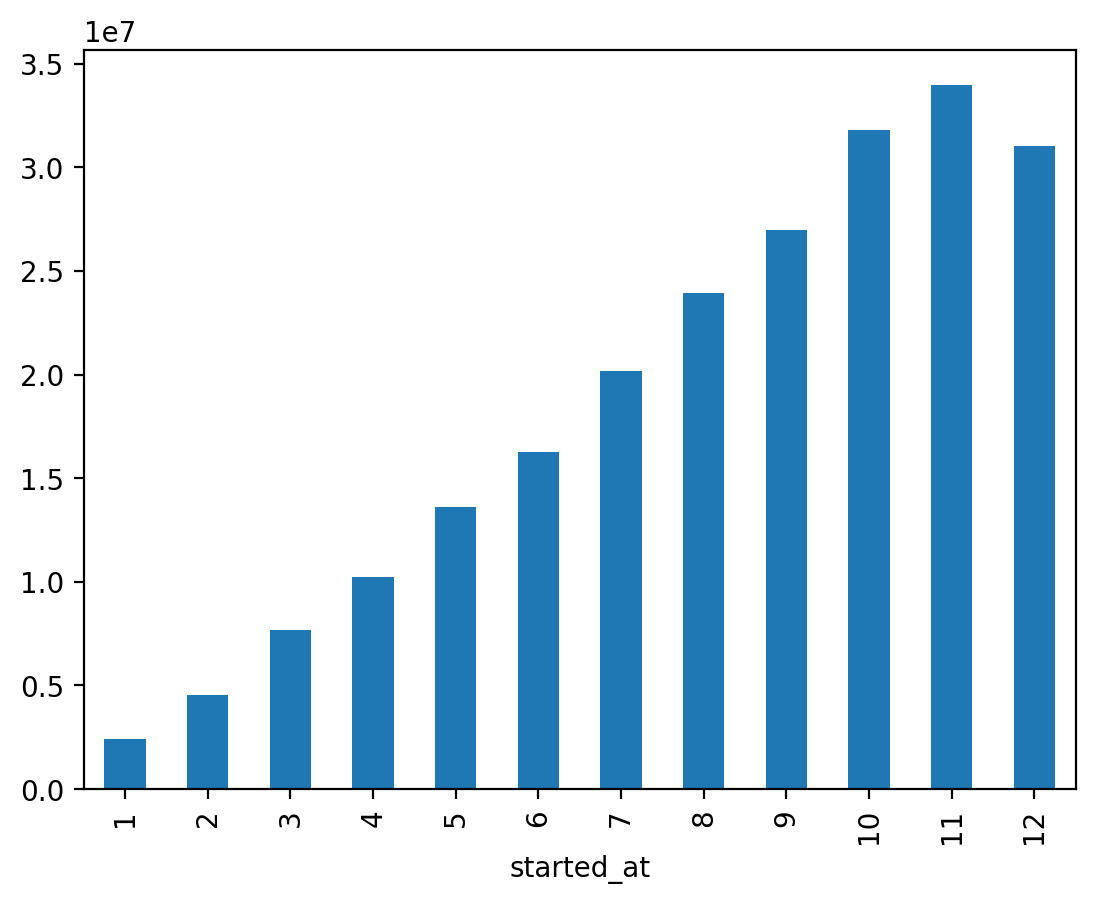

In [23]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [24]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .sort_values('votes', ascending=False).head(10) \
    .merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='left')[['name', 'votes']] \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,Smells Like Teen Spirit,111062
2,Believer,106921
3,Numb,101924
4,I Got Love,99490
5,Юность,86670
6,Way Down We Go,86246
7,Shape of You,85886
8,In The End,85244
9,Shape Of My Heart,85042
10,Life,84748


Наиболее популярные жанры

In [25]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .merge(tracks, on='track_id', how='left')[['votes', 'genre']] \
    .explode('genre') \
    .merge(catalog_names.query('type == "genre"'), left_on='genre', right_on='id', how='left')[['name', 'votes']] \
    .groupby('name').agg(votes=('votes', 'sum')).reset_index() \
    .sort_values('votes', ascending=False) \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,pop,55578312
2,rap,37799821
3,allrock,31092013
4,ruspop,26626241
5,rusrap,25303695
6,electronics,20120981
7,dance,16291557
8,rusrock,13166147
9,rock,12772644
10,metal,12437375


Треки, которые никто не прослушал

In [26]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,album,artist,genre


Неизвестные треки

In [27]:
interactions[~interactions['track_id'].isin(tracks['track_id'].unique())]

,user_id,track_id,track_seq,started_at


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [28]:
# Оставим взаимодействия с известными треками
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]
# Оставим треки с взаимодейсвиями
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]

In [29]:
# Удалим треки с пустыми свойствами
tracks_empty = tracks.apply(lambda x: len(x['album']) == 0 or len(x['artist']) == 0 or len(x['genre']) == 0, axis=1)
tracks = tracks[~tracks_empty]
# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

logging.info(f'Удалены треки, у которых не заполнены свойства в количестве: {tracks_empty.sum()}')

del tracks_empty

Удалены треки, у которых не заполнены свойства в количестве: 19023


In [31]:
# # Получим имена треков и удалим безымянные
# df_track = tracks.merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id') \
#     .reset_index()[['track_id', 'type', 'name', 'votes']]
    
# # Оставим только актуальные взаимодействия
# interactions = interactions[interactions['track_id'].isin(df_track['track_id'].unique())]  
# # Оставим только актуальные треки
# tracks = tracks[tracks['track_id'].isin(df_track['track_id'].unique())]  

In [44]:
# Развернем свойсва, получим имена и удалим безымянные

df_track = tracks.merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id') \
    .reset_index()[['track_id', 'type', 'name']]
df_track['id'] = df_track['track_id']

def explode_prop(prop: str):
    '''Разворачивает свойство "prop"'''
    df = tracks.explode(prop)[['track_id', prop]] \
        .rename(columns={prop: 'id'}) \
        .merge(catalog_names.query(f'type == "{prop}"'), on='id', how='inner') \
        # .rename(columns={prop: 'id', 'votes': 'votes_single'}) \
    # df['votes'] = 1
    # votes = df.groupby(['track_id', 'name']).agg(votes=('votes_single', 'sum'))
    # df = df.merge(votes, on=['track_id', 'name'])
    
    # df['rank'] = df.groupby(['track_id', 'name']).cumcount() + 1
    
    return df[['track_id', 'type', 'id', 'name']]  


df_album = explode_prop('album')
df_artist = explode_prop('artist')
df_genre = explode_prop('genre')

In [34]:
# # Сформируем развернутую таблицу треков
# tracks_exploded = pd.concat([
#     df_track,
#     df_album,
#     df_artist,
#     df_genre
# ]) #.fillna(-1).sort_values('votes', ascending=False)

In [45]:
# Удалим дубли
df_genre = df_genre[['track_id', 'type', 'name']] \
    .merge(df_genre.groupby(['name']).agg(id=('id', 'min')).reset_index(), on=['name'])

df_artist = df_artist.sort_values('id')
df_artist['rank'] = df_artist.groupby(['track_id', 'name']).cumcount() + 1
df_artist = df_artist.query('rank == 1').drop('rank', axis=1)

df_album = df_album.sort_values('id')
df_album['rank'] = df_album.groupby(['track_id', 'name']).cumcount() + 1
df_album = df_album.query('rank == 1').drop('rank', axis=1)

In [46]:
# Рассчитаем количество прослушиваний
tracks = tracks.merge(interactions.groupby(['track_id']).agg(votes=('user_id', 'count')), on='track_id')

def calc_rating(votes: np.array, base: int = 10):
    '''Расчитывает рейтинг'''
    pow_votes = np.emath.logn(base, np.max(votes)) 
    return np.power(votes, 1/pow_votes).round(2)


def calc_rating_prop(df: pd.DataFrame):
    '''Расчитывает рейтинг набора'''
    df = df.rename(columns={'votes': 'votes_single'})
        
    votes = df.groupby(['id']).agg(votes=('votes_single', 'sum')).reset_index()
    votes['rating'] = calc_rating(votes['votes'])
    
    return df.merge(votes, on='id') \
        .drop('votes_single', axis=1)


df_track['rating'] = calc_rating(df_track['votes'].values)
df_album = calc_rating_prop(df_album)
df_artist = calc_rating_prop(df_artist)
df_genre = calc_rating_prop(df_genre)

KeyError: 'votes'

In [40]:
# Сформируем развернутую таблицу треков
tracks_exploded = pd.concat([
    df_track,
    df_album,
    df_artist,
    df_genre
])

del df_track, df_album, df_artist, df_genre

In [42]:
# Удалим треки, у которы не все свойства заполнены
incomplete_tracks = tracks_exploded.groupby('track_id').agg(prop_count=('type', 'nunique')).reset_index().query('prop_count != 4')
tracks_exploded = tracks_exploded[~tracks_exploded['track_id'].isin(incomplete_tracks['track_id'])]

# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks_exploded['track_id'].unique())]

In [40]:
# def prop_agg(data: pd.DataFrame, prop: str):
#     '''Рассчитывает агрегированные знайения свойства "prop"'''
#     df_agg = data.query('type == @prop').groupby(['track_id']) \
#         .agg(count=('id', 'count'), rating_mean=('rating', 'mean'), votes_mean=('votes', 'mean')) \
#         .reset_index()
    
#     for col in df_agg.columns:
#         if col == 'track_id':
#             df_agg[col] = df_agg[col]
#             continue
#         df_agg[col] = df_agg[col].round(2)
    
#     arr_agg = []
#     for _, row in df_agg.iterrows():
#         agg = {}
#         for col in df_agg.columns:
#             if col == 'track_id':
#                 continue
#             agg[col] = row[col]
#         arr_agg.append(str(agg))
    
#     df_agg[f'agg_{prop}'] = arr_agg
#     return df_agg[['track_id', f'agg_{prop}']]

# tracks_agg = pd.DataFrame(data=tracks_exploded['track_id'].unique(), columns=['track_id'])
# tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'genre'), on='track_id')
# tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'album'), on='track_id')
# tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'artist'), on='track_id')

In [38]:
# Удалим не популярные треки
tracks = tracks.query('votes >= 1000')
tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(tracks['track_id'].unique())]
# tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

In [39]:
# Оставим по 5 самых популярных значений свойств трека
tracks_exploded['rank'] = tracks_exploded.groupby(['track_id', 'type']).cumcount(ascending=True) + 1
tracks_exploded = tracks_exploded.query('rank <= 5')

In [42]:
# Преобразуем треки в удобный формат
tracks_arr = []

for _, data in tracks_exploded.groupby('track_id'):
    
    new_row = {
        'track_id': None,
        'track': None,
        # 'votes': None,
        # 'rating': None,
        'genre': None,
        'album': None,
        'artist': None
    }
    
    for row in data.itertuples():
        if row.type == 'track':
            new_row['track_id'] = row.track_id
            new_row['track'] = row.name
            new_row['votes'] = row.votes
            new_row['rating'] = row.rating
            continue
        
        if new_row[row.type] is None:
            new_row[row.type] = []
        
        value = {
            'track_id': row.track_id,
            'id': row.id,
            'name': row.name,
            # 'votes': row.votes,
            # 'rating': row.rating,
            # 'rank': row.rank
        }
        
        new_row[row.type].append(value)
    
    tracks_arr.append(new_row)
    
tracks = pd.DataFrame(tracks_arr)
tracks['genre'] = tracks['genre'].astype(str)
tracks['album'] = tracks['album'].astype(str)
tracks['artist'] = tracks['artist'].astype(str)

del tracks_exploded

In [40]:
# Рассчитаем показатели пользвателей
users_agg = interactions.groupby('user_id').agg(events_count=('track_id', 'count'))
interactions = interactions.merge(users_agg, on='user_id', how='left')

del users_agg

In [41]:
# # Удалим пользвателей, у которых менее 10 взаимодействий
# interactions = interactions.query('events_count > 10')

# Оставим 10 последних взаимодействий для каждого пользователя
interactions['rank'] = interactions.groupby('user_id').cumcount(ascending=False) + 1
interactions = interactions.query('rank <= 10')

# Оставим только актуальные треки
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]
tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(tracks['track_id'].unique())]
tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

In [43]:
# Добавим трекам агрегированные данные
tracks = tracks.merge(tracks_agg, on='track_id')
tracks.rename(columns={'track': 'name'}, inplace=True)

del tracks_agg

In [44]:
# Добавим взаимодействиям рейтинги треков
interactions = interactions.merge(tracks[['track_id', 'votes', 'rating']], on='track_id', how='left')

In [45]:
interactions.shape, tracks.shape

((13023329, 8), (39847, 10))

In [46]:
# Упорядочим данные
tracks.sort_values('votes', ascending=False, inplace=True)
interactions.sort_values('votes', ascending=False, inplace=True)

# EDA преобразованных данных

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

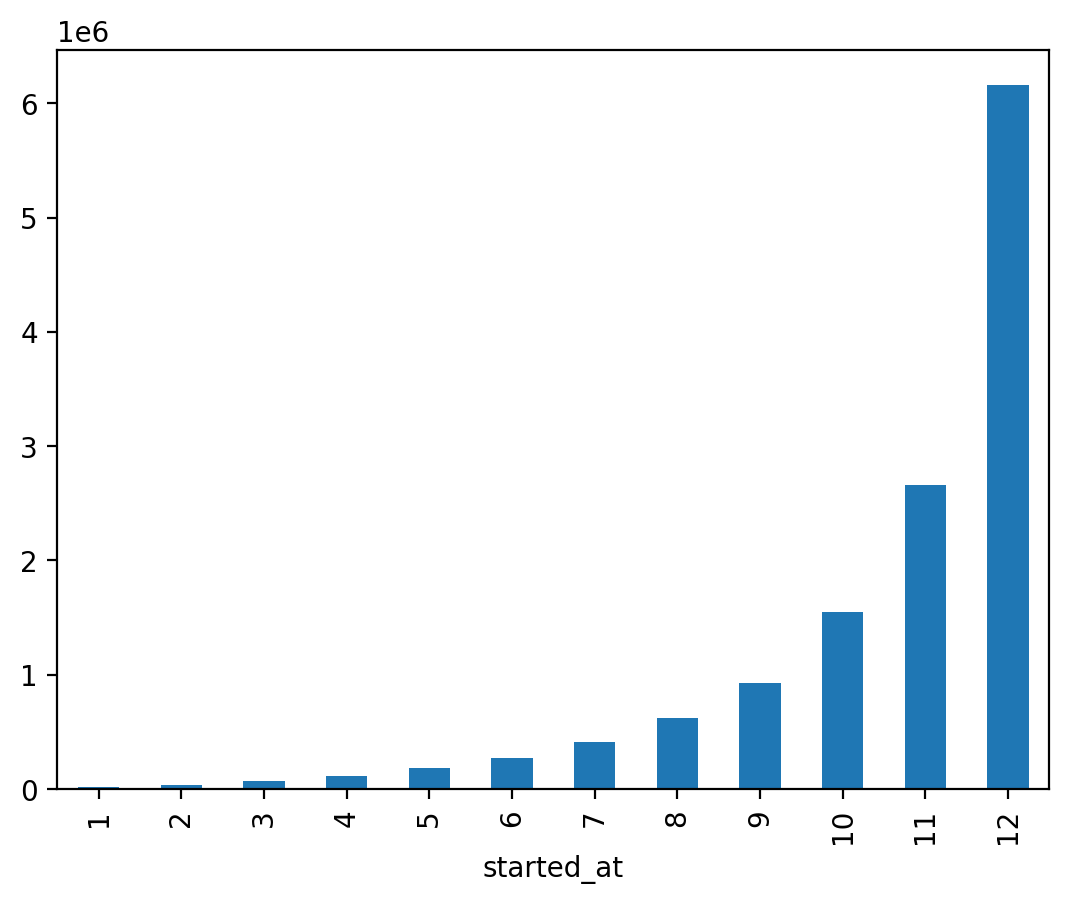

In [47]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [48]:
tracks[['track_id', 'name', 'votes', 'rating']] \
    .head(10) \
    .merge(pd.DataFrame(tracks['artist'].apply(eval).explode('artist').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'artist'}), on='track_id') \
    .merge(pd.DataFrame(tracks['album'].apply(eval).explode('album').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'album'}), on='track_id') \
    .merge(pd.DataFrame(tracks['genre'].apply(eval).explode('genre').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'genre'}), on='track_id') \
    .set_index([pd.Index(range(1, 11))])

,track_id,name,votes,rating,artist,album,genre
1,53404,Smells Like Teen Spirit,111062,10.00,Nirvana,Skiing Music,allrock
2,33311009,Believer,106921,9.92,Imagine Dragons,Throwback Hits,allrock
3,178529,Numb,101924,9.83,Linkin Park,Meteora,metal
4,35505245,I Got Love,99490,9.78,Miyagi & Эндшпиль,I Got Love,rap
5,65851540,Юность,86670,9.52,Dabro,Юность,pop
6,24692821,Way Down We Go,86246,9.51,KALEO,Summer Music 2016,indie
7,32947997,Shape of You,85886,9.50,Ed Sheeran,Pop,pop
8,51241318,In The End,85244,9.49,Tommee Profitt,Fall Fall Fall,rnb
9,795836,Shape Of My Heart,85042,9.48,Sting,Сентиментальные рок-песни,pop
10,45499814,Life,84748,9.48,Zivert,Made in Russia,pop


Наиболее популярные жанры

In [ ]:
pd.DataFrame(tracks['genre'].apply(eval).explode('genre').to_list()) \
    .drop(['track_id', 'rank'], axis=1) \
    .drop_duplicates() \
    .sort_values('votes', ascending=False) \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,id,name,votes,rating
1,11,pop,9241782868620,10.00
2,75,rap,4846390650052,9.51
3,102,allrock,3684587248434,9.32
4,68,electronics,2298427117008,8.98
5,3,rusrap,1668981114810,8.76
6,20,ruspop,1243604885204,8.57
7,47,metal,899359023625,8.36
8,16,dance,841149379467,8.31
9,44,foreignrap,728972206146,8.22
10,14,rock,704716535880,8.20


Треки, которые никто не прослушал

In [ ]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,name,votes,rating,genre,album,artist,agg_genre,agg_album,agg_artist


Неизвестные треки

In [51]:
interactions[~interactions['track_id'].isin(tracks['track_id'].unique())]

,user_id,track_id,track_seq,started_at,events_count,rank,votes,rating


Распределение рейтингов

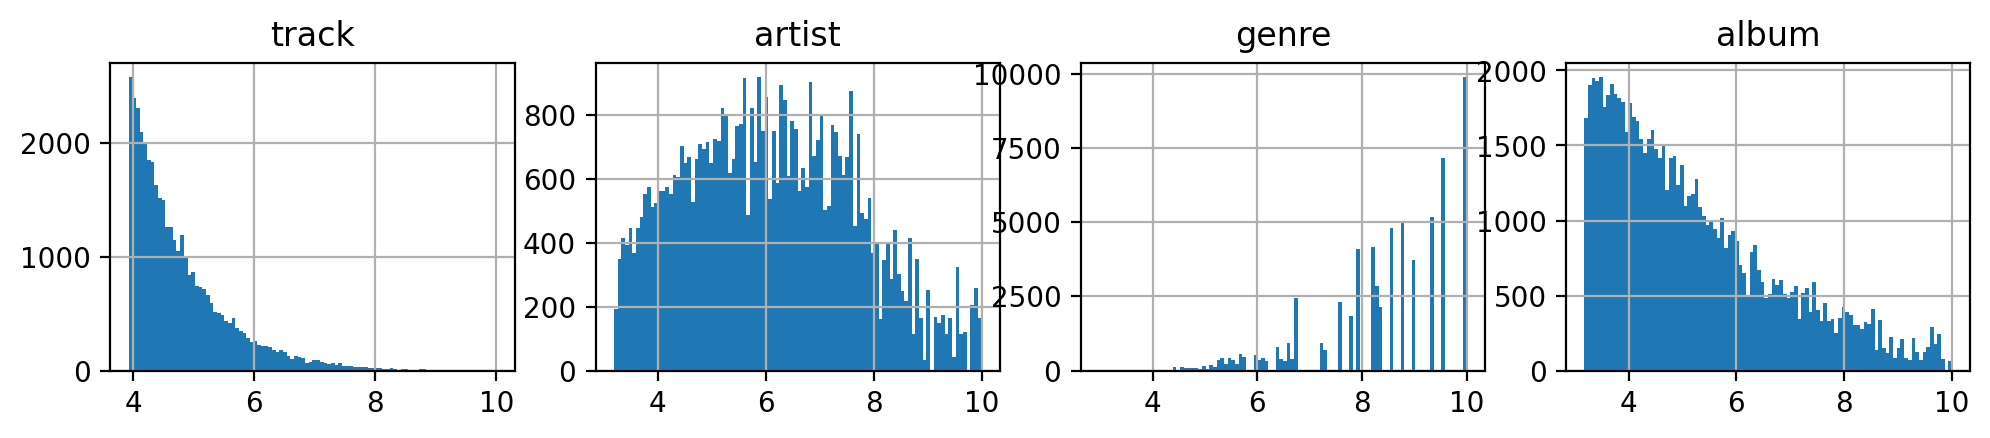

In [52]:
fig, axs = plt.subplots(nrows=1, ncols=4)
fig.set_size_inches(12, 2)

tracks['rating'].hist(bins=100, ax=axs[0])
axs[0].set_title('track')

def show_prop_rating(prop: str, ax):
    pd.DataFrame(tracks[prop].apply(eval).explode(prop).to_list())['rating'].hist(bins=100, ax=ax)
    ax.set_title(prop)

show_prop_rating('artist', axs[1])
show_prop_rating('genre', axs[2])
show_prop_rating('album', axs[3])

plt.show()

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [53]:
tracks.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions.rename(columns={'track_id': 'item_id'}, inplace=True)

tracks.to_parquet('data/items.parquet')
interactions.to_parquet('data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [2]:
del tracks
del interactions
del catalog_names

NameError: name 'tracks' is not defined

# === ЭТАП 3 ===

In [1]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
items = pd.read_parquet('data/items.parquet')
events = pd.read_parquet('data/events.parquet')

In [3]:
import sklearn.preprocessing

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events['user_id'])
events['user_id_enc'] = user_encoder.transform(events['user_id'])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items['item_id'])
items['item_id_enc'] = item_encoder.transform(items['item_id'])
events['item_id_enc'] = item_encoder.transform(events['item_id'])

In [4]:
events

,user_id,item_id,track_seq,started_at,events_count,rank,votes,rating,user_id_enc,item_id_enc
5615721,592791,53404,2,2022-10-06,10,9,111062,10.00,586503,701
5288603,558272,53404,2,2022-11-13,9,8,111062,10.00,552350,701
8829292,931910,53404,1,2022-08-02,10,10,111062,10.00,922010,701
3422103,361278,53404,1,2022-06-18,6,6,111062,10.00,357438,701
5189866,547834,53404,4,2022-08-06,13,10,111062,10.00,542032,701
...,...,...,...,...,...,...,...,...,...,...
5554598,586311,43532551,75,2022-11-28,45,6,1000,3.93,580107,24241
12492709,1318597,37784932,160,2022-08-06,81,6,1000,3.93,1304536,20669
2705822,285600,37784932,198,2022-11-04,138,5,1000,3.93,282614,20669
7797211,822998,95728562,512,2022-12-31,452,1,1000,3.93,814217,39565


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [4]:
train_split_date = pd.to_datetime('2022-12-16').to_datetime64()

train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

events_train.shape, events_test.shape

((9110491, 9), (3912838, 9))

In [5]:

# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

len(users_train), len(users_test), len(common_users)

(1113710, 702781, 456576)

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [6]:
# import scipy
# import sklearn.preprocessing

# # перекодируем идентификаторы пользователей: 
# # из имеющихся в последовательность 0, 1, 2, ...
# user_encoder = sklearn.preprocessing.LabelEncoder()
# user_encoder.fit(events['user_id'])
# events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
# events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])

# # перекодируем идентификаторы объектов: 
# # из имеющихся в последовательность 0, 1, 2, ...
# item_encoder = sklearn.preprocessing.LabelEncoder()
# item_encoder.fit(items['item_id'])
# items['item_id_enc'] = item_encoder.transform(items['item_id'])
# events_train['item_id_enc'] = item_encoder.transform(events_train['item_id'])
# events_test['item_id_enc'] = item_encoder.transform(events_test['item_id'])

In [9]:
events_train

,user_id,item_id,track_seq,started_at,events_count,rank,votes,rating,user_id_enc
5615721,592791,53404,2,2022-10-06,10,9,111062,10.00,586503
5288603,558272,53404,2,2022-11-13,9,8,111062,10.00,552350
8829292,931910,53404,1,2022-08-02,10,10,111062,10.00,922010
3422103,361278,53404,1,2022-06-18,6,6,111062,10.00,357438
5189866,547834,53404,4,2022-08-06,13,10,111062,10.00,542032
...,...,...,...,...,...,...,...,...,...
731327,77291,95728562,461,2022-11-09,271,9,1000,3.93,76450
5554598,586311,43532551,75,2022-11-28,45,6,1000,3.93,580107
12492709,1318597,37784932,160,2022-08-06,81,6,1000,3.93,1304536
2705822,285600,37784932,198,2022-11-04,138,5,1000,3.93,282614


In [8]:
import scipy

# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train['rating'],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8) 

KeyError: 'item_id_enc'

In [32]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=10, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

100%|██████████| 10/10 [00:31<00:00,  3.19s/it]


In [33]:
user_item_matrix_train.shape, len(user_encoder.classes_)

((1359913, 39847), 1359915)

In [34]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(user_item_matrix_train.shape[0])
# user_ids_encoded = range(len(user_encoder.classes_))
# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False,
    N=10) 

In [35]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    'user_id_enc': user_ids_encoded,
    'item_id_enc': item_ids_enc.tolist(), 
    'score': als_scores.tolist()})
als_recommendations = als_recommendations.explode(['item_id_enc', 'score'], ignore_index=True)

# приводим типы данных
als_recommendations['item_id_enc'] = als_recommendations['item_id_enc'].astype('int')
als_recommendations['score'] = als_recommendations['score'].astype('float')

# получаем изначальные идентификаторы
als_recommendations['user_id'] = user_encoder.inverse_transform(als_recommendations['user_id_enc'])
als_recommendations['item_id'] = item_encoder.inverse_transform(als_recommendations['item_id_enc'])
als_recommendations = als_recommendations.drop(columns=['user_id_enc', 'item_id_enc']) 

In [36]:
als_recommendations.shape

(13599130, 3)

In [37]:
als_recommendations.sample(8).T

,1441032,12662835,11430153,2063648,12351098,5205343,13102562,7972554
score,8.238161e-01,2.027426e-01,3.388961e-01,5.450240e-02,1.864880e-01,9.132298e-02,0.0,5.032359e-01
user_id,1.456300e+05,1.279938e+06,1.155368e+06,2.085390e+05,1.248435e+06,5.260940e+05,1324367.0,8.058540e+05
item_id,6.856271e+07,8.278314e+07,7.819500e+07,5.151648e+07,6.686959e+07,6.156556e+07,861.0,6.359153e+07


In [39]:
# Сохраним результат
als_recommendations.to_parquet('data/personal_als.parquet') 

Анализ результатов

In [40]:
als_recommendations.shape, events_train.shape

((13599130, 3), (9110491, 10))

array([[<Axes: title={'center': 'score'}>]], dtype=object)

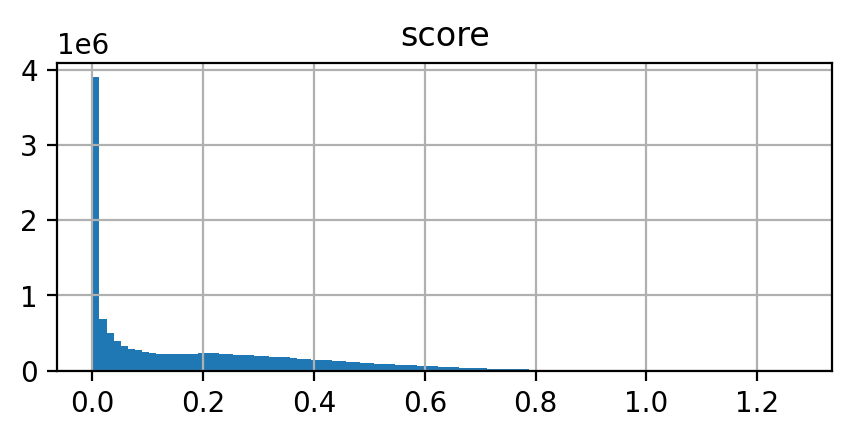

In [41]:
als_recommendations[['score']].hist(bins=100, figsize=(5, 2))

In [42]:
als_recommendations = (
    als_recommendations
    .merge(events[['user_id', 'item_id', 'rating']]
    .rename(columns={'rating': 'rating_test'}), 
    on=['user_id', 'item_id'], how='left')
) 

In [43]:
isnull_sum = als_recommendations['rating_test'].isnull().sum()
als_recommendations.shape[0], isnull_sum, als_recommendations.shape[0] - isnull_sum

(13599130, 12714626, 884504)

In [44]:
als_recommendations.query('~rating_test.isnull()').sample(8)

,score,user_id,item_id,rating_test
8208076,0.331991,829663,99246251,6.75
1123187,0.493966,113523,44279380,8.69
4224750,0.481657,426984,93126179,8.75
1131586,0.400830,114374,82783144,8.15
2304570,0.505200,232883,83063895,9.07
5030682,0.627114,508452,84382282,8.90
3489843,0.514313,352716,98901753,6.89
8087360,0.484629,817458,93390818,8.06


Проверка метрик на адекватность

In [45]:
import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    ''' подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    '''
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg 

In [46]:
ndcg_at_5_scores = als_recommendations.query('~rating_test.isnull()') \
    .groupby('user_id').apply(lambda x: compute_ndcg(x['rating_test'], x['score'], k=5)) 

In [47]:
logging.info(f'personal_als NDCG@5: {ndcg_at_5_scores.mean()}') 

NDCG@5: 0.997311827764771


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [9]:
items = pd.read_parquet('data/items.parquet')
events = pd.read_parquet('data/events.parquet')

In [14]:
import scipy
import sklearn.preprocessing

genres = pd.DataFrame(items['genre'].apply(eval).explode('genre').to_list()).drop(['rank'], axis=1)



In [17]:
genres.sample(8).T

,24940,40036,10732,62339,40755,43546,32978,61666
track_id,39331756,39294176,54292716,437915,31920262,81131081,59290137,90721688
id,20,3,11,49,70,70,3,75
name,ruspop,rusrap,pop,newage,indie,indie,rusrap,rap
votes,1243604885204,1668981114810,9241782868620,6098634789,348019389960,348019389960,1668981114810,4846390650052
rating,8.57,8.76,10.0,5.68,7.77,7.77,8.76,9.51


In [43]:
import scipy
import sklearn.preprocessing


def get_genres(items: pd.DataFrame):
    '''
        Извлекает список жанров по всем трекам,
        подсчитывает долю голосов по каждому их них
    '''
    
    genres = pd.DataFrame(items['genre'].apply(eval).explode('genre').to_list()) \
        .drop(['track_id', 'rank'], axis=1) \
        .drop_duplicates() \
        .sort_values('votes', ascending=False)
        
    # перекодируем идентификаторы пользователей: 
    # из имеющихся в последовательность 0, 1, 2, ...
    user_encoder = sklearn.preprocessing.LabelEncoder()
    user_encoder.fit(events['user_id'])
    events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
    events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])        
        
    genres['score'] = genres['votes'] / genres['votes'].sum()
    return genres

genres = get_genres(items)

print(genres.shape)
genres.head(10)

(107, 5)


,id,name,votes,rating,score
9,11,pop,9241782868620,10.00,0.319958
7,75,rap,4846390650052,9.51,0.167786
0,102,allrock,3684587248434,9.32,0.127563
31,68,electronics,2298427117008,8.98,0.079573
8,3,rusrap,1668981114810,8.76,0.057781
10,20,ruspop,1243604885204,8.57,0.043055
5,47,metal,899359023625,8.36,0.031137
21,16,dance,841149379467,8.31,0.029121
82,44,foreignrap,728972206146,8.22,0.025238
1,14,rock,704716535880,8.20,0.024398


In [55]:
import scipy
import sklearn.preprocessing

def get_item2genre_matrix(items: pd.DataFrame, genres: pd.DataFrame):

    df = pd.DataFrame(items['genre'].apply(eval).explode('genre').to_list()) \
        .drop(['rank'], axis=1)
    print(df)

    # genre_names_to_id = genres.reset_index().set_index('name')['id'].to_dict()
    
    # print(df['votes'].index.to_list())
    # # list to build CSR matrix
    genres_csr_data = df['rating'].to_list()
    genres_csr_row_idx = df['track_id'].to_list()
    genres_csr_col_idx = df['id'].to_list()
    
    print(genres_csr_data)
    
    genres_csr = scipy.sparse.csr_matrix((genres_csr_data, (genres_csr_row_idx, genres_csr_col_idx))) #, shape=(len(items), len(genres)))
    # нормализуем, чтобы сумма оценок принадлежности к жанру была равна 1
    genres_csr = sklearn.preprocessing.normalize(genres_csr, norm='l1', axis=1)    
    
    # for item_idx, (k, v) in enumerate(items.iterrows()):
    #     if v['genre_and_votes'] is None:
    #         continue
    #     for genre_name, votes in v['genre_and_votes'].items():
    #         genre_idx = genre_names_to_id[genre_name]
    #         genres_csr_data.append(int(votes))
    #         genres_csr_row_idx.append(item_idx)
    #         genres_csr_col_idx.append(genre_idx)

    # matrix = np.array([
    #     df['votes'].to_list(),
    #     df['track_id'].to_list(),
    #     df['id'].to_list()])
    # genres_csr = scipy.sparse.csr_matrix(matrix)
    # # нормализуем, чтобы сумма оценок принадлежности к жанру была равна 1
    # genres_csr = sklearn.preprocessing.normalize(genres_csr, norm='l1', axis=1)
    
    # return df
    return genres_csr 

get_item2genre_matrix(items, genres)

       track_id   id         name          votes  rating
0         53404  102      allrock  3684587248434    9.32
1         53404   14         rock   704716535880    8.20
2         53404   13  alternative   433806232924    7.90
3      33311009  102      allrock  3684587248434    9.32
4      33311009   14         rock   704716535880    8.20
...         ...  ...          ...            ...     ...
65932  61632682   75          rap  4846390650052    9.51
65933  61632682    3       rusrap  1668981114810    8.76
65934  31226139   11          pop  9241782868620   10.00
65935  31226139   20       ruspop  1243604885204    8.57
65936    787433   13  alternative   433806232924    7.90

[65937 rows x 5 columns]
[9.32, 8.2, 7.9, 9.32, 8.2, 8.36, 6.03, 9.51, 8.76, 10.0, 8.57, 7.77, 10.0, 6.71, 10.0, 9.32, 8.2, 10.0, 8.57, 6.71, 7.9, 8.31, 7.77, 7.56, 9.32, 8.2, 7.77, 9.32, 8.2, 7.56, 6.36, 8.98, 9.32, 8.2, 7.9, 10.0, 8.57, 7.77, 10.0, 8.57, 9.51, 8.76, 10.0, 6.77, 9.32, 8.2, 8.98, 8.31, 6.62, 7.77,

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 65937 stored elements and shape (101016327, 1543)>

In [57]:
row = np.array([0, 0, 10, 2, 2, 2])
col = np.array([0, 2, 2, 0, 1, 2])
data = np.array([10, 20, 10, 20, 10, 20])
# scipy.sparse.csr_matrix((data, (row, col)), shape=(3, 3)).toarray()
scipy.sparse.csr_matrix((data, (row, col))).toarray()

array([[10,  0, 20],
       [ 0,  0,  0],
       [20, 10, 20],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0,  0],
       [ 0,  0, 10]])

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.